## Importing Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
#create a DataFrame

df = pd.read_csv("./data/cluster.csv")

In [4]:
df.shape

(2240, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 2240 non-null   int64  
 1   Education           2240 non-null   int64  
 2   Marital Status      2240 non-null   int64  
 3   Parental Status     2240 non-null   int64  
 4   Children            2240 non-null   int64  
 5   Income              2240 non-null   float64
 6   Total_spending      2240 non-null   float64
 7   Days_as_Customer    2240 non-null   float64
 8   Recency             2240 non-null   int64  
 9   Wines               2240 non-null   int64  
 10  Fruits              2240 non-null   int64  
 11  Meat                2240 non-null   int64  
 12  Fish                2240 non-null   float64
 13  Sweets              2240 non-null   int64  
 14  Gold                2240 non-null   float64
 15  Web                 2240 non-null   int64  
 16  Catalo

In [6]:
df.describe()

,Age,Education,Marital Status,Parental Status,Children,Income,Total_spending,Days_as_Customer,Recency,Wines,...,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Promo,NumWebVisitsMonth,cluster
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,57.147768,2.393750,0.644643,0.715179,0.950446,51865.874554,605.779408,4662.582143,49.109375,302.112946,...,32.115848,21.937946,39.487723,4.084821,2.662054,5.790179,2.325000,0.297768,5.316518,1.107589
std,11.771725,1.124797,0.478728,0.451430,0.751803,20936.104821,602.189559,202.122512,28.962453,331.057356,...,40.361485,27.540334,39.927508,2.778714,2.923101,3.250958,1.932238,0.678381,2.426645,0.851940
min,30.000000,0.000000,0.000000,0.000000,0.000000,1730.000000,5.000000,4309.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49.000000,2.000000,0.000000,0.000000,0.000000,35538.750000,68.750000,4489.750000,24.000000,23.750000,...,3.000000,1.000000,9.000000,2.000000,0.000000,3.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,2.000000,1.000000,1.000000,1.000000,51381.500000,396.000000,4664.500000,49.000000,173.500000,...,12.000000,8.000000,24.000000,4.000000,2.000000,5.000000,2.000000,0.000000,6.000000,1.000000
75%,67.000000,3.000000,1.000000,1.000000,1.000000,68289.750000,1045.500000,4838.000000,74.000000,504.250000,...,50.000000,33.000000,56.000000,6.000000,4.000000,8.000000,3.000000,0.000000,7.000000,2.000000
max,94.000000,4.000000,1.000000,1.000000,3.000000,117416.250000,2510.625000,5008.000000,99.000000,1225.000000,...,120.500000,81.000000,126.500000,27.000000,28.000000,13.000000,15.000000,4.000000,20.000000,2.000000


**Split X and y**

**Why split The Data ?**

>Training Dataset is the part of Original Dataset that we use to train our ML model. The model learns on this data by running the algorithm and maps a function F(x) where “x” in the independent variable (inputs) for “y” where “y” is the dependent variable(output).

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [8]:
#define X and y
X = df.drop("cluster",axis=1)
y = df["cluster"] # target variable

# Grid Search

**Why do we use Grid Search?**

>GridSearchCV is a technique to search through the best parameter values from the given set of the grid of parameters. It is basically a cross-validation method. the model and the parameters are required to be fed in. Best parameter values are extracted and then the predictions are made.

**Select the best model**

>so here we have some list of the best classification algorithms we imported. Now we will compare each model's score and see which model is performing better than rest of the others

In [9]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier , GradientBoostingClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import SVC

from sklearn.metrics import classification_report , accuracy_score , ConfusionMatrixDisplay , precision_score , recall_score , f1_score , roc_curve , confusion_matrix

from xgboost import XGBClassifier

from catboost import CatBoostClassifier

from sklearn import metrics

In [10]:
models = {
    "Logisic_Regression" : LogisticRegression(),
    "Random_Forest" : RandomForestClassifier(),
    "Ada_Boost" : AdaBoostClassifier(),
    "Gradient_Boost" : GradientBoostingClassifier(),
    "k-neighbour" : KNeighborsClassifier(),
    "Decision_Tree" : DecisionTreeClassifier(),
    "XGB" : XGBClassifier(),
    "Cat_Boost" : CatBoostClassifier(verbose=False)
}

**We will create a generic function to check each model's performance so that we can compare those**

In [11]:
def evaluate_model(X,y,models):
    
    X_train , X_test , y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

    model_list = []
    score_list = []

    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train , y_train)

        #make prediction
        y_pred = model.predict(X_test)

        score = accuracy_score(y_test , y_pred)

        model_name = list(models.keys())[i]
        
        print(f"------Score for -- {model_name}")
        print(f"{score}\n")
        model_list.append(model_name)
        score_list.append(score)

    print()

    report = pd.DataFrame()
    report["Model_name"] = model_list
    report["Score"] = score_list
    return report

In [12]:
report = evaluate_model(X,y,models)

------Score for -- Logisic_Regression
0.8816964285714286

------Score for -- Random_Forest
0.9642857142857143

------Score for -- Ada_Boost
0.9375

------Score for -- Gradient_Boost
0.9620535714285714

------Score for -- k-neighbour
0.8236607142857143

------Score for -- Decision_Tree
0.9419642857142857

------Score for -- XGB
0.96875

------Score for -- Cat_Boost
0.9776785714285714




In [13]:
report.sort_values("Score",ascending=False).reset_index(drop=True)

,Model_name,Score
0,Cat_Boost,0.977679
1,XGB,0.968750
2,Random_Forest,0.964286
3,Gradient_Boost,0.962054
4,Decision_Tree,0.941964
5,Ada_Boost,0.937500
6,Logisic_Regression,0.881696
7,k-neighbour,0.823661


**From the report above we can see that the logistic regression model performed the best, so we will continue training our model using logistic regression algorithm.**

**Split into Train and test data**

**>> Do you know why we split the train and test dataset?**

>The train test split technique can be used for classification and regression problems to test machine learning algorithms. The procedure takes the given dataset and splits it into two subsets: **Training data/train set:** it is used to train the algorithm and fit the machine learning model then we have test data/test set which is basically a different data for which we know the values but this data was never shown to the model before. Thus if the model after training is performing good on test set as well then we can say that the Machine Learning model is good.

In [14]:
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.3 , random_state=42)

In [15]:
X_train

,Age,Education,Marital Status,Parental Status,Children,Income,Total_spending,Days_as_Customer,Recency,Wines,...,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Promo,NumWebVisitsMonth
994,72,2,0,1,2,64587.0,108.0,4316.0,49,66,...,16,0.0,6,20.0,1,1,4,2,0,3
2162,69,2,1,1,1,47320.0,414.0,4641.0,10,200,...,111,50.0,15,19.0,5,1,8,6,0,6
906,65,2,0,0,0,86429.0,1449.0,4529.0,10,464,...,556,29.0,18,37.0,7,4,7,0,1,2
572,48,0,0,1,1,38593.0,177.0,4598.0,42,51,...,49,17.0,24,24.0,4,1,3,3,0,8
1877,68,2,1,0,0,72905.0,1515.0,4468.0,52,407,...,445,120.5,81,126.5,3,7,9,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,57,2,1,1,2,44078.0,41.0,4319.0,17,24,...,10,2.0,0,4.0,2,0,3,2,0,5
1095,47,2,0,1,1,61825.0,424.0,4635.0,56,162,...,100,55.0,30,27.0,4,2,8,1,0,4
1130,75,3,1,1,1,67381.0,957.0,4839.0,67,815,...,53,11.0,0,70.0,2,2,9,4,1,7
1294,63,4,0,1,2,48918.0,62.0,4387.0,21,52,...,9,0.0,0,1.0,1,0,4,2,0,4


# Let's do hyperparameter tuning

**And what's it actually?**

>A Machine Learning model is defined as a mathematical model with a number of parameters that need to be learned from the data. By training a model with existing data, we are able to fit the model parameters. However, there is another kind of parameter, known as Hyperparameters, that cannot be directly learned from the regular training process. They are usually fixed before the actual training process begins. These parameters express important properties of the model such as its complexity or how fast it should learn.

In [17]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': np.random.randint(100,500, 10),
    'multi_class': ['auto', 'ovr', 'multinomial'],
    "C":np.logspace(-3,3,7),
    "penalty":["l1","l2"]

    
}

logreg_cv = RandomizedSearchCV(
    LogisticRegression(),
    params,
    n_iter=50,
    cv=5,
    n_jobs=-1,
    random_state=42
)
logreg_cv.fit(X_train,y_train)

print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'solver': 'newton-cg', 'penalty': 'l2', 'multi_class': 'multinomial', 'max_iter': 414, 'C': 0.1}
accuracy : 0.9700189251337987


**So we got our best parameters. Let's now train the model with those parameters.**

In [18]:
model = LogisticRegression(C=10,max_iter=220,multi_class="auto",penalty="l1",solver="liblinear")

model.fit(X_train , y_train)

y_pred = model.predict(X_test)

accuracy_score = accuracy_score(y_test , y_pred)
classification_report = classification_report(y_test , y_pred)

print(f"The accuracy score is {accuracy_score}\n")
print(f"{classification_report}")

The accuracy score is 0.9672619047619048

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       235
           1       0.98      0.96      0.97       179
           2       0.97      0.98      0.98       258

    accuracy                           0.97       672
   macro avg       0.97      0.97      0.97       672
weighted avg       0.97      0.97      0.97       672



# **Confusion matrix of the model**

**What is confusion matrix ?**

>The confusion matrix is a matrix used to determine the performance of the classification models for a given set of test data. It can only be determined if the true values for test data are known. The matrix itself can be easily understood, but the related terminologies may be confusing.

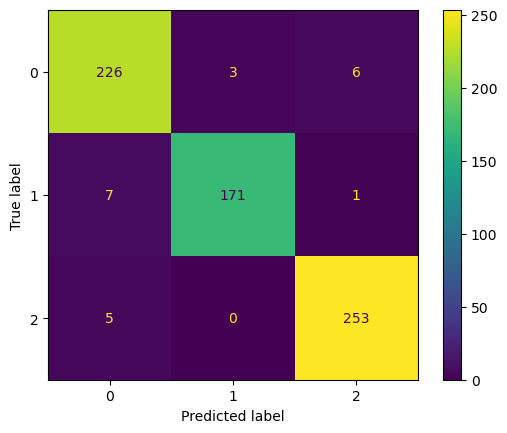

In [19]:
ConfusionMatrixDisplay.from_estimator(model,X_test , y_test)


# **Reports**

>**We can see, that the model performed pretty well.**

>**we have used logistic regression as it performed well than other models**

>**We got a good accuracy while predicting the test dataset.**

Save A Model Under Model Section

In [21]:
import pickle
import os

os.makedirs("./data/model",exist_ok=True)

with open("./data/model/model.pkl","wb") as f:
    pickle.dump(model,f)